# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Konfigurasi tampilan
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [23]:
#Type your code here
df = pd.read_csv('healthcare_stroke_raw.csv', sep=';')

print(f'Dataset berhasil dimuat!')
print(f'Dimensi dataset : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Kolom           : {df.columns.tolist()}')

Dataset berhasil dimuat!
Dimensi dataset : 5110 baris x 12 kolom
Kolom           : ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [24]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [26]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Shape dataset: (5110, 12)

STATISTIK DESKRIPTIF


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



CEK MISSING VALUES
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Ada missing values.

DISTRIBUSI FITUR NUMERIK


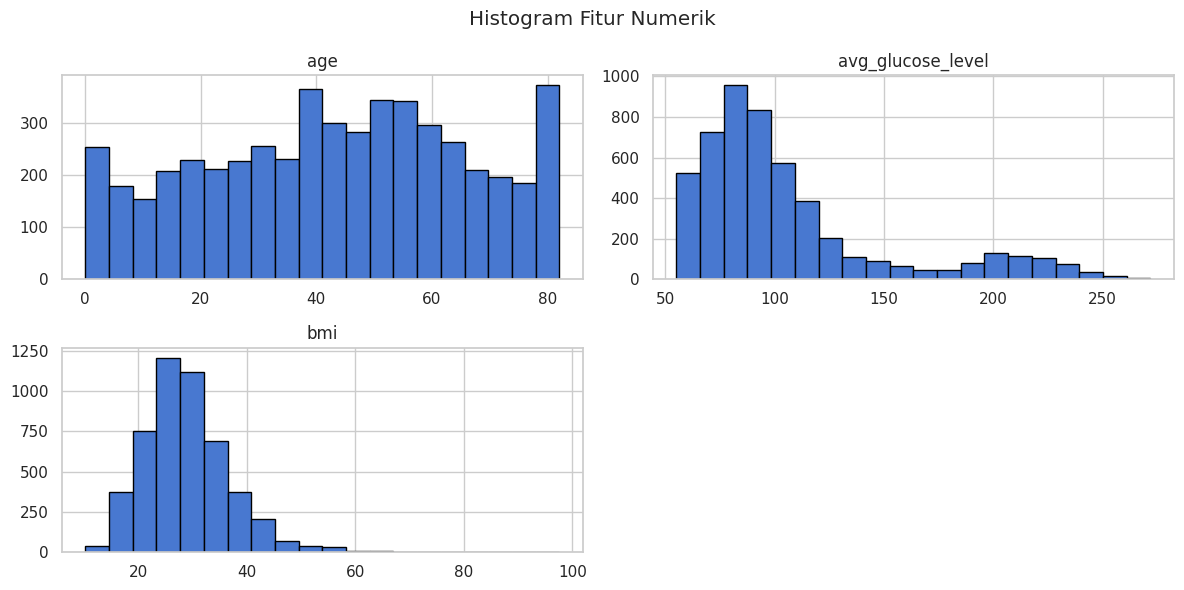


DISTRIBUSI TARGET (stroke)


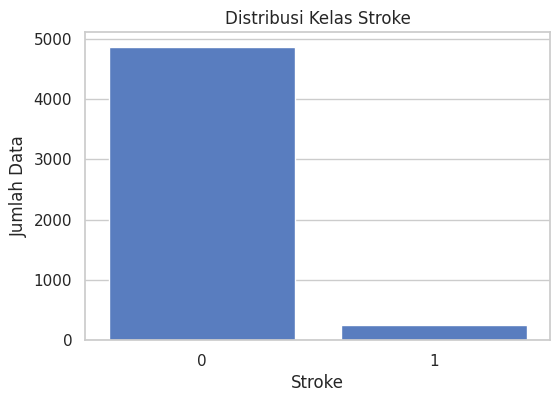

stroke
0    4861
1     249
Name: count, dtype: int64

DISTRIBUSI FITUR KATEGORIK


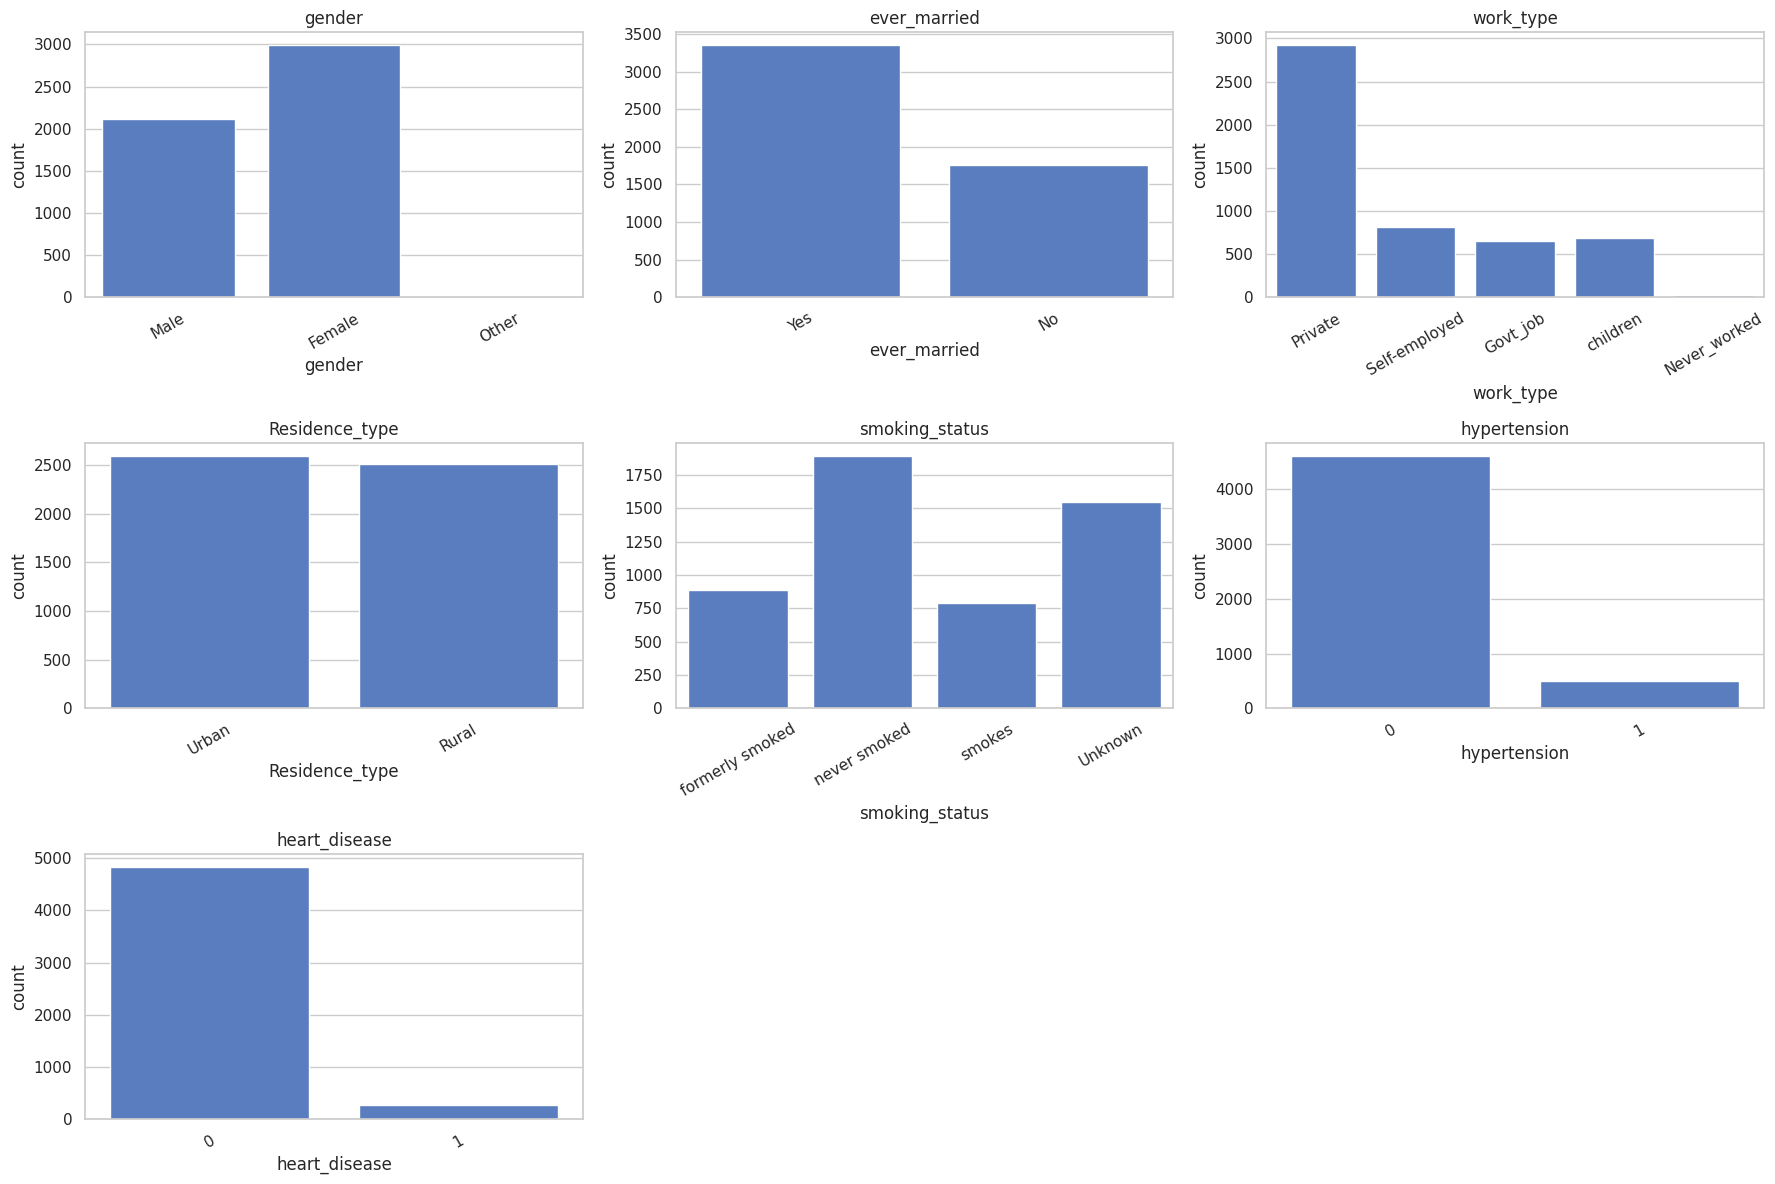


HEATMAP KORELASI


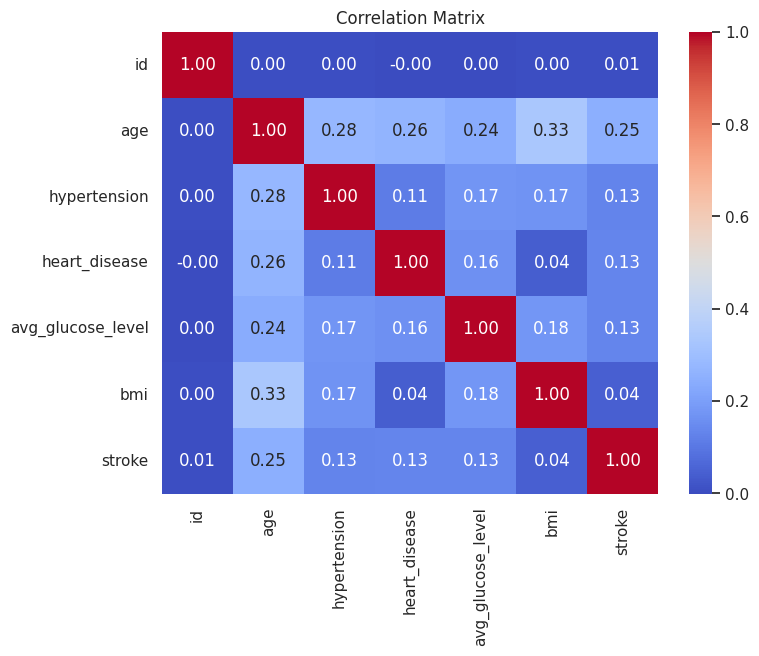


DETEKSI OUTLIER DENGAN BOXPLOT


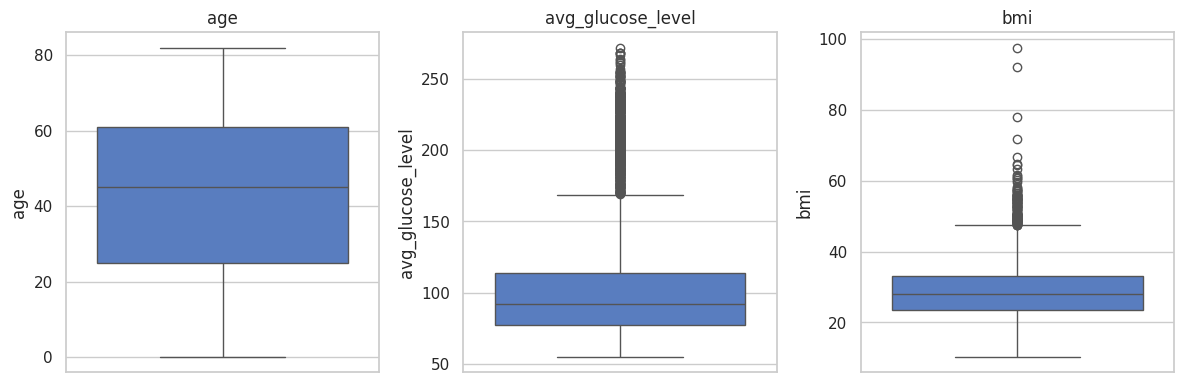

In [28]:
# =====================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("INFO DATASET")
print("="*50)
print(df.info())
print("\nShape dataset:", df.shape)

# =====================================================
# STATISTIK DESKRIPTIF
# =====================================================

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)

display(df.describe())

# =====================================================
# CEK MISSING VALUES
# =====================================================

print("\n" + "="*50)
print("CEK MISSING VALUES")
print("="*50)

missing = df.isnull().sum()

print(missing)

if missing.sum() == 0:
    print("Tidak ada missing values.")
else:
    print("Ada missing values.")

# =====================================================
# DISTRIBUSI FITUR NUMERIK
# =====================================================

print("\n" + "="*50)
print("DISTRIBUSI FITUR NUMERIK")
print("="*50)

num_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

df[num_cols].hist(
    bins=20,
    figsize=(12,6),
    edgecolor='black'
)

plt.suptitle("Histogram Fitur Numerik")
plt.tight_layout()
plt.show()

# =====================================================
# DISTRIBUSI TARGET
# =====================================================

print("\n" + "="*50)
print("DISTRIBUSI TARGET (stroke)")
print("="*50)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='stroke'
)

plt.title("Distribusi Kelas Stroke")
plt.xlabel("Stroke")
plt.ylabel("Jumlah Data")

plt.show()

print(df['stroke'].value_counts())

# =====================================================
# DISTRIBUSI FITUR KATEGORIK
# =====================================================

print("\n" + "="*50)
print("DISTRIBUSI FITUR KATEGORIK")
print("="*50)

cat_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status',
    'hypertension',
    'heart_disease'
]

plt.figure(figsize=(18,12))

for i, col in enumerate(cat_cols, 1):

    plt.subplot(3,3,i)

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# =====================================================
# HEATMAP KORELASI
# =====================================================

print("\n" + "="*50)
print("HEATMAP KORELASI")
print("="*50)

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

# =====================================================
# DETEKSI OUTLIER DENGAN BOXPLOT
# =====================================================

print("\n" + "="*50)
print("DETEKSI OUTLIER DENGAN BOXPLOT")
print("="*50)

plt.figure(figsize=(12,4))

for i, col in enumerate(num_cols, 1):

    plt.subplot(1,3,i)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [29]:
print("\n" + "="*50)
print("PREPROCESSING")
print("="*50)

# =====================================================
# COPY DATASET
# =====================================================

df_clean = df.copy()

print("Shape awal:", df_clean.shape)

# =====================================================
# HAPUS KOLOM TIDAK RELEVAN
# =====================================================

# id hanya identifier
df_clean.drop(columns=['id'], inplace=True)

print("Kolom setelah drop id:")
print(df_clean.columns.tolist())

# =====================================================
# MISSING VALUES
# =====================================================

print("\n=== PENANGANAN MISSING VALUES ===")

missing_cols = df_clean.columns[df_clean.isnull().any()].tolist()

if missing_cols:

    for col in missing_cols:

        if df_clean[col].dtype in ['float64', 'int64']:

            median_val = df_clean[col].median()

            df_clean[col].fillna(
                median_val,
                inplace=True
            )

            print(
                f"{col} diisi median = {median_val}"
            )

        else:

            mode_val = df_clean[col].mode()[0]

            df_clean[col].fillna(
                mode_val,
                inplace=True
            )

            print(
                f"{col} diisi modus = {mode_val}"
            )

else:
    print("Tidak ada missing values.")

# =====================================================
# HAPUS DATA DUPLIKAT
# =====================================================

print("\n=== HAPUS DUPLIKAT ===")

duplicate_count = df_clean.duplicated().sum()

print("Jumlah duplikat:", duplicate_count)

df_clean.drop_duplicates(inplace=True)

print("Shape setelah hapus duplikat:",
      df_clean.shape)

# =====================================================
# ENCODING DATA KATEGORIK
# =====================================================

print("\n=== ENCODING DATA KATEGORIK ===")

from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df_clean[col] = le.fit_transform(
        df_clean[col].astype(str)
    )

    encoders[col] = le

    print(f"{col} berhasil di-encode")

# =====================================================
# BINNING AGE
# =====================================================

print("\n=== BINNING AGE ===")

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0,18,35,50,65,100],
    labels=[
        'Child',
        'Young Adult',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

age_encoder = LabelEncoder()

df_clean['age_group'] = age_encoder.fit_transform(
    df_clean['age_group']
)

print("Binning age berhasil")

# =====================================================
# DETEKSI & PENANGANAN OUTLIER
# =====================================================

print("\n=== PENANGANAN OUTLIER ===")

outlier_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    df_clean[col] = np.where(
        df_clean[col] < lower,
        lower,
        df_clean[col]
    )

    df_clean[col] = np.where(
        df_clean[col] > upper,
        upper,
        df_clean[col]
    )

    print(
        f"{col}: lower={lower:.2f}, upper={upper:.2f}"
    )

# =====================================================
# FEATURE & TARGET
# =====================================================

X = df_clean.drop(columns=['stroke'])
y = df_clean['stroke']

# =====================================================
# STANDARISASI
# =====================================================

print("\n=== STANDARISASI ===")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(
    "Shape setelah scaling:",
    X_scaled_df.shape
)

# =====================================================
# GABUNGKAN KEMBALI
# =====================================================

df_preprocessed = pd.concat(
    [
        X_scaled_df,
        y.reset_index(drop=True)
    ],
    axis=1
)

# =====================================================
# SIMPAN DATASET
# =====================================================

import os

os.makedirs(
    'preprocessing',
    exist_ok=True
)

df_preprocessed.to_csv(
    'preprocessing/stroke_preprocessed.csv',
    index=False
)

print(
    "\nDataset berhasil disimpan:"
)

print(
    "preprocessing/stroke_preprocessed.csv"
)

# =====================================================
# HASIL AKHIR
# =====================================================

print("\nContoh hasil preprocessing:")

display(
    df_preprocessed.head()
)


PREPROCESSING
Shape awal: (5110, 12)
Kolom setelah drop id:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

=== PENANGANAN MISSING VALUES ===
bmi diisi median = 28.1

=== HAPUS DUPLIKAT ===
Jumlah duplikat: 0
Shape setelah hapus duplikat: (5110, 11)

=== ENCODING DATA KATEGORIK ===
gender berhasil di-encode
ever_married berhasil di-encode
work_type berhasil di-encode
Residence_type berhasil di-encode
smoking_status berhasil di-encode

=== BINNING AGE ===
Binning age berhasil

=== PENANGANAN OUTLIER ===
age: lower=-29.00, upper=115.00
avg_glucose_level: lower=21.98, upper=169.36
bmi: lower=10.30, upper=46.30

=== STANDARISASI ===
Shape setelah scaling: (5110, 11)

Dataset berhasil disimpan:
preprocessing/stroke_preprocessed.csv

Contoh hasil preprocessing:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,age_group,stroke
0,1.188073,1.051434,-0.328602,4.185032,0.723884,-0.153836,0.984080,2.058363,1.110872,-0.351781,0.730986,1
1,-0.840344,0.786070,-0.328602,-0.238947,0.723884,0.763438,-1.016178,2.058363,-0.082921,0.581552,0.021250,1
2,1.188073,1.626390,-0.328602,4.185032,0.723884,-0.153836,-1.016178,0.148256,0.535043,0.581552,0.730986,1
3,-0.840344,0.255342,-0.328602,-0.238947,0.723884,-0.153836,0.984080,2.058363,0.801890,1.514885,-1.398222,1
4,-0.840344,1.582163,3.043196,-0.238947,0.723884,0.763438,-1.016178,2.058363,-0.658751,0.581552,0.730986,1
